# N2 - Attention + Logistic Regression

**Models**:
1. **Baseline 1 + is_evening**: PhoBERT-v2-Pretrained + TF-IDF + Handcraft (with is_evening) + Attention
2. **Baseline 1 + hour_sin_cos**: PhoBERT-v2-Pretrained + TF-IDF + Handcraft (with hour_sin/cos) + Attention
3. **Baseline 2 + is_evening**: PhoBERT-v2-Finetuned + Handcraft (with is_evening) + Attention
4. **Baseline 2 + hour_sin_cos**: PhoBERT-v2-Finetuned + Handcraft (with hour_sin/cos) + Attention

**Gate Attention**: Per-dimension learnable gates (sigmoid) for feature selection

**Evaluation**: 10-Fold CV → Paired T-Test
**Metrics**: AUC, F1, Precision, Recall

In [20]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")

Project root: d:\Vietnamese-Fake-News-Detection
Device: cuda


In [21]:
# Paths
ENCODED_DIR = PROJECT_ROOT / 'data' / 'encoded'
ANALYSIS_DIR = PROJECT_ROOT / 'data' / 'analysis'
TRAINED_DIR = PROJECT_ROOT / 'data' / 'trained' / 'early_fusion'
MODEL_DIR = PROJECT_ROOT / 'model' / 'early_fusion' / 'attention_logreg'
FIGURES_DIR = PROJECT_ROOT / 'data' / 'figures' / 'training'

# Ensure directories exist
TRAINED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Random state
RANDOM_STATE = 42
N_FOLDS = 10

## 1. Load Data

In [22]:
# Load CSV with labels and handcraft features
df = pd.read_csv(ENCODED_DIR / 'final_data_shuffled.csv')
labels = df['label'].values

print(f"Samples: {len(df)}")
print(f"Label distribution: {dict(pd.Series(labels).value_counts())}")

Samples: 4736
Label distribution: {0: 3929, 1: 807}


In [23]:
# Load selected features
with open(ANALYSIS_DIR / 'selected_features.txt', 'r') as f:
    all_features = [line.strip() for line in f.readlines()]

# Split into two variants
features_is_evening = [f for f in all_features if f not in ['feat_hour_sin', 'feat_hour_cos']]
features_hour_sin_cos = [f for f in all_features if f != 'feat_is_evening']

print(f"Features with is_evening ({len(features_is_evening)}): {features_is_evening}")
print(f"Features with hour_sin_cos ({len(features_hour_sin_cos)}): {features_hour_sin_cos}")

Features with is_evening (10): ['feat_avg_word_length', 'feat_comment_ratio', 'feat_digit_ratio', 'feat_fake_ratio', 'feat_is_evening', 'feat_like_ratio', 'feat_num_exclamation', 'feat_num_question', 'feat_num_sentences', 'feat_num_urls']
Features with hour_sin_cos (11): ['feat_avg_word_length', 'feat_comment_ratio', 'feat_digit_ratio', 'feat_fake_ratio', 'feat_hour_cos', 'feat_hour_sin', 'feat_like_ratio', 'feat_num_exclamation', 'feat_num_question', 'feat_num_sentences', 'feat_num_urls']


In [24]:
# Load embeddings
phobert_pretrain = np.load(ENCODED_DIR / 'phobertv2' / 'pretrained_embeddings.npy')
phobert_finetune = np.load(ENCODED_DIR / 'phobertv2' / 'finetuned_embeddings.npy')
tfidf_emb = np.load(ENCODED_DIR / 'tfidf' / 'tfidf_embeddings.npy')

print(f"PhoBERT pretrained: {phobert_pretrain.shape}")
print(f"PhoBERT finetuned: {phobert_finetune.shape}")
print(f"TF-IDF: {tfidf_emb.shape}")

# Handcraft features
handcraft_is_evening = df[features_is_evening].values
handcraft_hour_sin_cos = df[features_hour_sin_cos].values

print(f"\nHandcraft (is_evening): {handcraft_is_evening.shape}")
print(f"Handcraft (hour_sin_cos): {handcraft_hour_sin_cos.shape}")

PhoBERT pretrained: (4736, 88)
PhoBERT finetuned: (4736, 68)
TF-IDF: (4736, 120)

Handcraft (is_evening): (4736, 10)
Handcraft (hour_sin_cos): (4736, 11)


## 2. Attention Module

In [25]:
class GateAttention(nn.Module):
    """
    Gate Attention: Per-dimension learnable gates.
    Each dimension has its own weight (sigmoid gate) from 0 to 1.
    Total params = total_dim (e.g., 768+300+12 = 1080 gates)
    """
    def __init__(self, total_dim):
        """
        Args:
            total_dim: total number of input dimensions (all features concatenated)
        """
        super().__init__()
        self.total_dim = total_dim
        
        # Learnable gate for each dimension
        # Initialize slightly positive so sigmoid starts ~0.5
        self.gates = nn.Parameter(torch.zeros(total_dim))
        
    def forward(self, x):
        """
        Args:
            x: input tensor [batch, total_dim]
        Returns:
            gated output [batch, total_dim], gate values [total_dim]
        """
        # Apply sigmoid to get gates in [0, 1]
        gate_values = torch.sigmoid(self.gates)
        
        # Apply gates element-wise
        output = x * gate_values
        
        return output, gate_values
    
    def get_gate_values(self):
        """Get current gate values"""
        with torch.no_grad():
            return torch.sigmoid(self.gates).cpu().numpy()

In [26]:
class GateAttentionModel(nn.Module):
    """End-to-end model with gate attention and classification head"""
    def __init__(self, total_dim):
        super().__init__()
        self.gate_attention = GateAttention(total_dim)
        self.classifier = nn.Linear(total_dim, 1)
        
    def forward(self, x):
        gated, gate_values = self.gate_attention(x)
        logits = self.classifier(gated)
        return logits, gate_values
    
    def get_gated_features(self, x):
        """Get gated features for use with sklearn"""
        with torch.no_grad():
            gated, gate_values = self.gate_attention(x)
        return gated.cpu().numpy(), gate_values.cpu().numpy()

## 3. Model Configurations

In [27]:
# Model configurations
MODEL_CONFIGS = {
    'B1_is_evening': {
        'name': 'Baseline1 + is_evening + Attention',
        'baseline': 1,
        'time_type': 'is_evening',
        'embeddings': [phobert_pretrain, tfidf_emb],
        'handcraft': handcraft_is_evening,
        'feature_names': features_is_evening,
        'group_names': ['phobert_pretrain', 'tfidf', 'handcraft']
    },
    'B1_hour_sin_cos': {
        'name': 'Baseline1 + hour_sin_cos + Attention',
        'baseline': 1,
        'time_type': 'hour_sin_cos',
        'embeddings': [phobert_pretrain, tfidf_emb],
        'handcraft': handcraft_hour_sin_cos,
        'feature_names': features_hour_sin_cos,
        'group_names': ['phobert_pretrain', 'tfidf', 'handcraft']
    },
    'B2_is_evening': {
        'name': 'Baseline2 + is_evening + Attention',
        'baseline': 2,
        'time_type': 'is_evening',
        'embeddings': [phobert_finetune],
        'handcraft': handcraft_is_evening,
        'feature_names': features_is_evening,
        'group_names': ['phobert_finetune', 'handcraft']
    },
    'B2_hour_sin_cos': {
        'name': 'Baseline2 + hour_sin_cos + Attention',
        'baseline': 2,
        'time_type': 'hour_sin_cos',
        'embeddings': [phobert_finetune],
        'handcraft': handcraft_hour_sin_cos,
        'feature_names': features_hour_sin_cos,
        'group_names': ['phobert_finetune', 'handcraft']
    }
}

print("Model configurations:")
for key, config in MODEL_CONFIGS.items():
    dims = [e.shape[1] for e in config['embeddings']] + [config['handcraft'].shape[1]]
    total_dim = sum(dims)
    print(f"  {key}: {config['name']}")
    print(f"         Total dims: {total_dim} gates ({dims})")

Model configurations:
  B1_is_evening: Baseline1 + is_evening + Attention
         Total dims: 218 gates ([88, 120, 10])
  B1_hour_sin_cos: Baseline1 + hour_sin_cos + Attention
         Total dims: 219 gates ([88, 120, 11])
  B2_is_evening: Baseline2 + is_evening + Attention
         Total dims: 78 gates ([68, 10])
  B2_hour_sin_cos: Baseline2 + hour_sin_cos + Attention
         Total dims: 79 gates ([68, 11])


## 4. Training Functions

In [28]:
def find_optimal_threshold(y_true, y_prob):
    """Find threshold that maximizes F1 score"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5

def evaluate_fold(y_true, y_prob, threshold=0.5):
    """Calculate metrics for a fold"""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'threshold': threshold
    }

In [29]:
def train_gate_model(X_train, y_train, total_dim, epochs=50, lr=0.01, batch_size=64):
    """
    Train gate attention model to learn per-dimension gates.
    Returns trained model.
    """
    model = GateAttentionModel(total_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Handle class imbalance
    pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Convert to tensors
    X_tensor = torch.FloatTensor(X_train).to(DEVICE)
    y_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
    
    n_samples = len(y_train)
    indices = np.arange(n_samples)
    
    model.train()
    for epoch in range(epochs):
        np.random.shuffle(indices)
        
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            batch_idx = indices[start:end]
            
            batch_X = X_tensor[batch_idx]
            batch_y = y_tensor[batch_idx]
            
            optimizer.zero_grad()
            logits, _ = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
    
    return model

In [30]:
def prepare_features(config):
    """Concatenate all features"""
    parts = config['embeddings'] + [config['handcraft']]
    return np.hstack(parts)

def train_evaluate_cv_gate(config, y, n_folds=10, random_state=42):
    """Train and evaluate with K-Fold CV using gate attention + LogReg"""
    kf = StratifiedKFold(n_splits=n_folds, shuffle=False)
    fold_results = []
    all_gate_values = []
    
    # Concatenate all features
    X = prepare_features(config)
    total_dim = X.shape[1]
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Train gate attention model
        gate_model = train_gate_model(X_train_scaled, y_train, total_dim, epochs=30)
        
        # Get gated features
        gate_model.eval()
        X_train_tensor = torch.FloatTensor(X_train_scaled).to(DEVICE)
        X_val_tensor = torch.FloatTensor(X_val_scaled).to(DEVICE)
        
        X_train_gated, _ = gate_model.get_gated_features(X_train_tensor)
        X_val_gated, gate_values = gate_model.get_gated_features(X_val_tensor)
        
        # Store gate values
        all_gate_values.append(gate_model.gate_attention.get_gate_values())
        
        # Train LogReg on gated features
        logreg = LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=random_state
        )
        logreg.fit(X_train_gated, y_train)
        
        # Predict
        y_prob = logreg.predict_proba(X_val_gated)[:, 1]
        
        # Find optimal threshold
        opt_threshold = find_optimal_threshold(y_val, y_prob)
        
        # Evaluate
        metrics = evaluate_fold(y_val, y_prob, opt_threshold)
        metrics['fold'] = fold + 1
        fold_results.append(metrics)
    
    return fold_results, np.array(all_gate_values)

In [31]:
def train_final_gate_model(config, y, random_state=42):
    """Train final gate attention + LogReg model on full data"""
    X = prepare_features(config)
    total_dim = X.shape[1]
    
    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train gate model
    gate_model = train_gate_model(X_scaled, y, total_dim, epochs=50)
    
    # Get gated features
    gate_model.eval()
    X_tensor = torch.FloatTensor(X_scaled).to(DEVICE)
    X_gated, _ = gate_model.get_gated_features(X_tensor)
    
    # Train LogReg
    logreg = LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=random_state
    )
    logreg.fit(X_gated, y)
    
    # Find optimal threshold
    y_prob = logreg.predict_proba(X_gated)[:, 1]
    opt_threshold = find_optimal_threshold(y, y_prob)
    
    gate_values = gate_model.gate_attention.get_gate_values()
    
    return gate_model, logreg, scaler, opt_threshold, gate_values

## 5. Train All Models

In [32]:
# Store results
all_results = {}
all_fold_metrics = {}

for model_key, config in tqdm(MODEL_CONFIGS.items(), desc="Training models"):
    print(f"\n{'='*60}")
    print(f"Training: {config['name']}")
    print(f"{'='*60}")
    
    # 10-Fold CV
    fold_results, gate_values_cv = train_evaluate_cv_gate(
        config, labels, n_folds=N_FOLDS, random_state=RANDOM_STATE
    )
    
    # Calculate mean metrics
    fold_df = pd.DataFrame(fold_results)
    mean_metrics = {
        'auc_mean': fold_df['auc'].mean(),
        'auc_std': fold_df['auc'].std(),
        'f1_mean': fold_df['f1'].mean(),
        'f1_std': fold_df['f1'].std(),
        'precision_mean': fold_df['precision'].mean(),
        'precision_std': fold_df['precision'].std(),
        'recall_mean': fold_df['recall'].mean(),
        'recall_std': fold_df['recall'].std(),
        'threshold_mean': fold_df['threshold'].mean()
    }
    
    print(f"\n10-Fold CV Results:")
    print(f"  AUC:       {mean_metrics['auc_mean']:.4f} ± {mean_metrics['auc_std']:.4f}")
    print(f"  F1:        {mean_metrics['f1_mean']:.4f} ± {mean_metrics['f1_std']:.4f}")
    print(f"  Precision: {mean_metrics['precision_mean']:.4f} ± {mean_metrics['precision_std']:.4f}")
    print(f"  Recall:    {mean_metrics['recall_mean']:.4f} ± {mean_metrics['recall_std']:.4f}")
    
    # Gate statistics per feature group
    mean_gates = gate_values_cv.mean(axis=0)
    dims = [e.shape[1] for e in config['embeddings']] + [config['handcraft'].shape[1]]
    offset = 0
    group_gate_means = []
    for i, (name, d) in enumerate(zip(config['group_names'], dims)):
        group_mean = mean_gates[offset:offset+d].mean()
        group_gate_means.append(group_mean)
        offset += d
    print(f"\nMean gate values by group: {dict(zip(config['group_names'], np.round(group_gate_means, 4)))}")
    
    # Train final model
    gate_model, logreg, scaler, opt_threshold, final_gates = train_final_gate_model(
        config, labels, RANDOM_STATE
    )
    print(f"Final threshold: {opt_threshold:.4f}")
    
    # Save results
    all_fold_metrics[model_key] = fold_df
    all_results[model_key] = {
        'config': config['name'],
        'baseline': config['baseline'],
        'time_type': config['time_type'],
        'mean_metrics': mean_metrics,
        'fold_results': fold_results,
        'gate_values': final_gates,
        'group_dims': dims,
        'group_names': config['group_names'],
        'gate_model': gate_model,
        'logreg': logreg,
        'scaler': scaler,
        'threshold': opt_threshold,
        'feature_names': config['feature_names']
    }

Training models:   0%|          | 0/4 [00:00<?, ?it/s]


Training: Baseline1 + is_evening + Attention

10-Fold CV Results:
  AUC:       0.9384 ± 0.0078
  F1:        0.7362 ± 0.0198
  Precision: 0.7277 ± 0.0924
  Recall:    0.7630 ± 0.0807

Mean gate values by group: {'phobert_pretrain': 0.4748, 'tfidf': 0.4216, 'handcraft': 0.5207}


Training models:  25%|██▌       | 1/4 [00:35<01:47, 35.74s/it]

Final threshold: 0.7352

Training: Baseline1 + hour_sin_cos + Attention

10-Fold CV Results:
  AUC:       0.9392 ± 0.0072
  F1:        0.7406 ± 0.0240
  Precision: 0.7505 ± 0.0809
  Recall:    0.7445 ± 0.0761

Mean gate values by group: {'phobert_pretrain': 0.4736, 'tfidf': 0.4227, 'handcraft': 0.4937}


Training models:  50%|█████     | 2/4 [01:10<01:10, 35.43s/it]

Final threshold: 0.7701

Training: Baseline2 + is_evening + Attention

10-Fold CV Results:
  AUC:       0.9768 ± 0.0071
  F1:        0.8840 ± 0.0202
  Precision: 0.8734 ± 0.0525
  Recall:    0.8984 ± 0.0380

Mean gate values by group: {'phobert_finetune': 0.4462, 'handcraft': 0.5026}


Training models:  75%|███████▌  | 3/4 [01:46<00:35, 35.65s/it]

Final threshold: 0.7429

Training: Baseline2 + hour_sin_cos + Attention

10-Fold CV Results:
  AUC:       0.9772 ± 0.0067
  F1:        0.8782 ± 0.0200
  Precision: 0.8840 ± 0.0550
  Recall:    0.8761 ± 0.0374

Mean gate values by group: {'phobert_finetune': 0.4439, 'handcraft': 0.486}


Training models: 100%|██████████| 4/4 [02:17<00:00, 34.29s/it]

Final threshold: 0.7480


## 6. Save Results & Models

In [33]:
# Save fold results
for model_key, fold_df in all_fold_metrics.items():
    output_path = TRAINED_DIR / f'gate_logreg_{model_key}_folds.csv'
    fold_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

# Save models (PyTorch + sklearn)
for model_key, result in all_results.items():
    model_path = MODEL_DIR / f'{model_key}_gate_model.pt'
    torch.save({
        'gate_model_state': result['gate_model'].state_dict(),
        'logreg': result['logreg'],
        'scaler': result['scaler'],
        'threshold': result['threshold'],
        'gate_values': result['gate_values'],
        'group_dims': result['group_dims'],
        'group_names': result['group_names'],
        'feature_names': result['feature_names'],
        'config': result['config']
    }, model_path)
    print(f"Saved: {model_path}")

Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\gate_logreg_B1_is_evening_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\gate_logreg_B1_hour_sin_cos_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\gate_logreg_B2_is_evening_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion\gate_logreg_B2_hour_sin_cos_folds.csv
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\attention_logreg\B1_is_evening_gate_model.pt
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\attention_logreg\B1_hour_sin_cos_gate_model.pt
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\attention_logreg\B2_is_evening_gate_model.pt
Saved: d:\Vietnamese-Fake-News-Detection\model\early_fusion\attention_logreg\B2_hour_sin_cos_gate_model.pt


## 7. Summary & Comparison

In [43]:
# Create summary table
summary_data = []
for model_key, result in all_results.items():
    m = result['mean_metrics']
    # Calculate mean gate per group
    gates = result['gate_values']
    dims = result['group_dims']
    names = result['group_names']
    offset = 0
    gate_strs = []
    for name, d in zip(names, dims):
        mean_gate = gates[offset:offset+d].mean()
        gate_strs.append(f"{name}:{mean_gate:.2f}")
        offset += d
    summary_data.append({
        'Model': result['config'],
        'Baseline': result['baseline'],
        'Time Feature': result['time_type'],
        'AUC': f"{m['auc_mean']:.4f}±{m['auc_std']:.4f}",
        'F1': f"{m['f1_mean']:.4f}±{m['f1_std']:.4f}",
        'Precision': f"{m['precision_mean']:.4f}±{m['precision_std']:.4f}",
        'Recall': f"{m['recall_mean']:.4f}±{m['recall_std']:.4f}",

        'Gate (mean)': ', '.join(gate_strs)
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY - GATE ATTENTION + LOGISTIC REGRESSION")
print("="*100)
display(summary_df)



SUMMARY - GATE ATTENTION + LOGISTIC REGRESSION


,Model,Baseline,Time Feature,AUC,F1,Precision,Recall,Gate (mean)
0,Baseline1 + is_evening + Attention,1,is_evening,0.9384±0.0078,0.7362±0.0198,0.7277±0.0924,0.7630±0.0807,"phobert_pretrain:0.43, tfidf:0.36, handcraft:0.48"
1,Baseline1 + hour_sin_cos + Attention,1,hour_sin_cos,0.9392±0.0072,0.7406±0.0240,0.7505±0.0809,0.7445±0.0761,"phobert_pretrain:0.42, tfidf:0.36, handcraft:0.44"
2,Baseline2 + is_evening + Attention,2,is_evening,0.9768±0.0071,0.8840±0.0202,0.8734±0.0525,0.8984±0.0380,"phobert_finetune:0.39, handcraft:0.41"
3,Baseline2 + hour_sin_cos + Attention,2,hour_sin_cos,0.9772±0.0067,0.8782±0.0200,0.8840±0.0550,0.8761±0.0374,"phobert_finetune:0.38, handcraft:0.40"


## 8. Paired T-Test

In [44]:
def paired_ttest(fold_df1, fold_df2, metric='f1'):
    scores1 = fold_df1[metric].values
    scores2 = fold_df2[metric].values
    t_stat, p_value = stats.ttest_rel(scores1, scores2)
    return t_stat, p_value, scores1.mean() - scores2.mean()

COMPARISON_PAIRS = [
    ('B1_is_evening', 'B1_hour_sin_cos', 'Baseline 1: is_evening vs hour_sin_cos'),
    ('B2_is_evening', 'B2_hour_sin_cos', 'Baseline 2: is_evening vs hour_sin_cos'),
    ('B1_is_evening', 'B2_is_evening', 'is_evening: Baseline 1 vs Baseline 2'),
    ('B1_hour_sin_cos', 'B2_hour_sin_cos', 'hour_sin_cos: Baseline 1 vs Baseline 2'),
]

print("Paired T-Test Results (F1 Score):")
print("="*80)

ttest_results = []
for model1, model2, desc in COMPARISON_PAIRS:
    t_stat, p_value, diff = paired_ttest(
        all_fold_metrics[model1], all_fold_metrics[model2], 'f1'
    )
    sig = "*" if p_value < 0.05 else ""
    print(f"\n{desc}")
    print(f"  t-stat: {t_stat:.4f}, p-value: {p_value:.4f} {sig}")
    print(f"  Mean diff: {diff:.4f}")
    
    ttest_results.append({
        'comparison': desc, 'model1': model1, 'model2': model2,
        't_stat': t_stat, 'p_value': p_value, 'significant': p_value < 0.05,
        'mean_diff': diff
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df.to_csv(TRAINED_DIR / 'gate_logreg_paired_ttest.csv', index=False)

Paired T-Test Results (F1 Score):

Baseline 1: is_evening vs hour_sin_cos
  t-stat: -1.2380, p-value: 0.2470 
  Mean diff: -0.0044

Baseline 2: is_evening vs hour_sin_cos
  t-stat: 2.0379, p-value: 0.0720 
  Mean diff: 0.0058

is_evening: Baseline 1 vs Baseline 2
  t-stat: -17.7458, p-value: 0.0000 *
  Mean diff: -0.1478

hour_sin_cos: Baseline 1 vs Baseline 2
  t-stat: -16.0752, p-value: 0.0000 *
  Mean diff: -0.1376


## 9. Visualizations

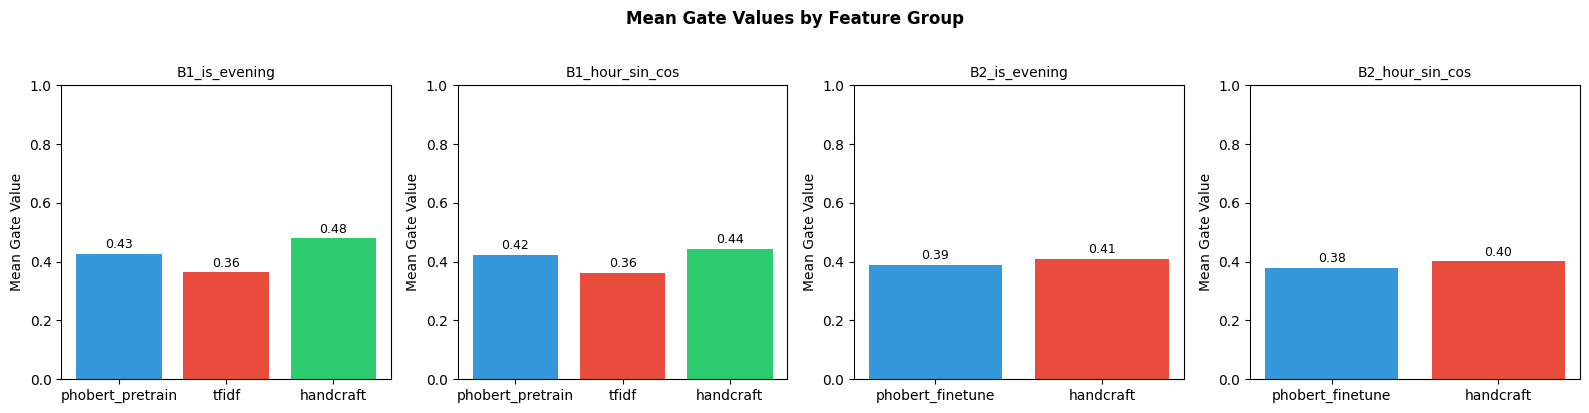

In [45]:
# Gate values visualization (mean per group)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (model_key, result) in zip(axes, all_results.items()):
    gates = result['gate_values']
    dims = result['group_dims']
    names = result['group_names']
    
    # Calculate mean gate per group
    offset = 0
    group_means = []
    for d in dims:
        group_means.append(gates[offset:offset+d].mean())
        offset += d
    
    bars = ax.bar(names, group_means, color=['#3498db', '#e74c3c', '#2ecc71'][:len(names)])
    ax.set_ylim(0, 1)
    ax.set_title(model_key, fontsize=10)
    ax.set_ylabel('Mean Gate Value')
    
    for bar, w in zip(bars, group_means):
        ax.text(bar.get_x() + bar.get_width()/2, w + 0.02, f'{w:.2f}', 
                ha='center', fontsize=9)

plt.suptitle('Mean Gate Values by Feature Group', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gate_logreg_gate_values.png', dpi=150, bbox_inches='tight')
plt.show()

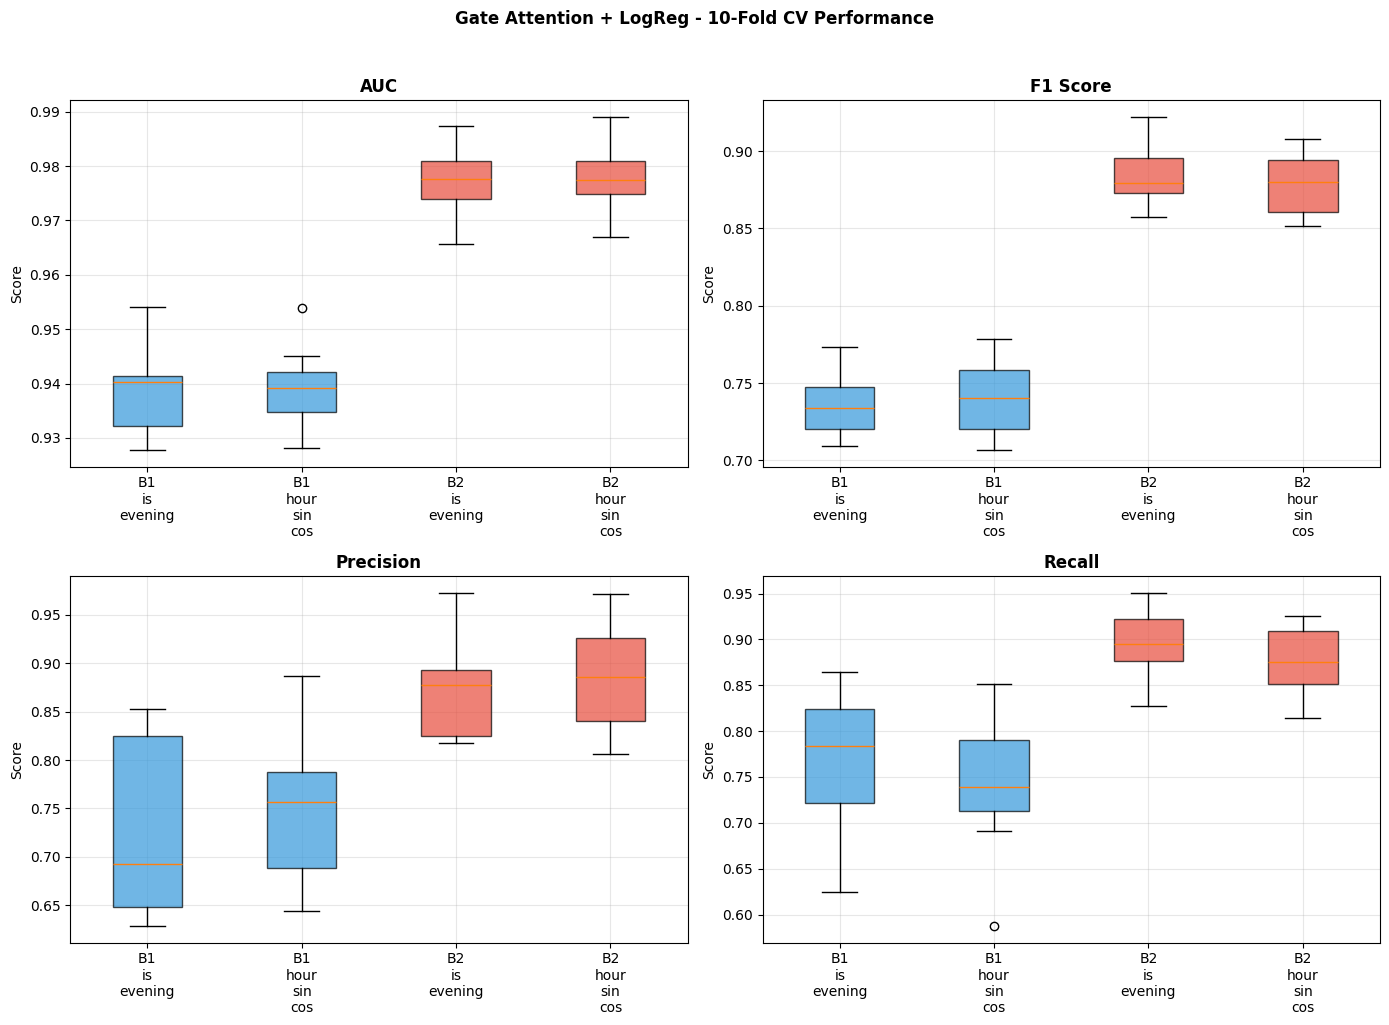

In [46]:
# Box plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['auc', 'f1', 'precision', 'recall']
titles = ['AUC', 'F1 Score', 'Precision', 'Recall']

for ax, metric, title in zip(axes.flatten(), metrics_to_plot, titles):
    data_to_plot = []
    labels_plot = []
    for model_key, fold_df in all_fold_metrics.items():
        data_to_plot.append(fold_df[metric].values)
        labels_plot.append(model_key.replace('_', '\n'))
    
    bp = ax.boxplot(data_to_plot, labels=labels_plot, patch_artist=True)
    
    colors = ['#3498db', '#3498db', '#e74c3c', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3)

plt.suptitle('Gate Attention + LogReg - 10-Fold CV Performance', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gate_logreg_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary

In [47]:
print("="*70)
print("GATE ATTENTION + LOGISTIC REGRESSION TRAINING COMPLETE")
print("="*70)

print(f"\n📊 Models trained: {len(all_results)}")
for key, result in all_results.items():
    m = result['mean_metrics']
    print(f"  • {result['config']}: F1={m['f1_mean']:.4f}, AUC={m['auc_mean']:.4f}")

print(f"\n📁 Output files:")
print(f"  • Fold results: {TRAINED_DIR}")
print(f"  • Models: {MODEL_DIR}")
print(f"  • Figures: {FIGURES_DIR}")

best_key = max(all_results.keys(), key=lambda k: all_results[k]['mean_metrics']['f1_mean'])
best_result = all_results[best_key]
print(f"\n🏆 Best model: {best_result['config']}")
print(f"   F1: {best_result['mean_metrics']['f1_mean']:.4f}")
# Show mean gate per group
_gates = best_result['gate_values']
_dims = best_result['group_dims']
_names = best_result['group_names']
_offset = 0
_gate_dict = {}
for _name, _d in zip(_names, _dims):
    _gate_dict[_name] = _gates[_offset:_offset+_d].mean()
    _offset += _d
print(f"   Gate means: {_gate_dict}")

GATE ATTENTION + LOGISTIC REGRESSION TRAINING COMPLETE

📊 Models trained: 4
  • Baseline1 + is_evening + Attention: F1=0.7362, AUC=0.9384
  • Baseline1 + hour_sin_cos + Attention: F1=0.7406, AUC=0.9392
  • Baseline2 + is_evening + Attention: F1=0.8840, AUC=0.9768
  • Baseline2 + hour_sin_cos + Attention: F1=0.8782, AUC=0.9772

📁 Output files:
  • Fold results: d:\Vietnamese-Fake-News-Detection\data\trained\early_fusion
  • Models: d:\Vietnamese-Fake-News-Detection\model\early_fusion\attention_logreg
  • Figures: d:\Vietnamese-Fake-News-Detection\data\figures\training

🏆 Best model: Baseline2 + is_evening + Attention
   F1: 0.8840
   Gate means: {'phobert_finetune': 0.3896977, 'handcraft': 0.40933338}
